In [6]:
# Cell 1 — Imports and reproducibility
import os
import random
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


In [7]:
# Cell 2 - Load dataset from workspace root
DATA_PATH = "liver_cancer_recurrence_dataset (2).csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found at root path: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())
print("\nTarget distribution:")
print(df["recurrence_within_2yr"].value_counts())
print("\nMissing values:", int(df.isna().sum().sum()))

Shape: (3000, 54)


,patient_id,tumor_size_cm,tumor_number,tumor_shape_irregularity,tumor_texture_entropy,tumor_density_hu,margin_definition,vascular_invasion_imaging,satellite_nodules,peritumoral_edema,...,shap_afp,shap_mvi_pathology,shap_cirrhosis,shap_texture_entropy,gradcam_activation_score,uncertainty_dropout_std,confidence_score,recurrence_probability,recurrence_within_2yr,time_to_recurrence_months
0,PT0001,5.37,1,0.197,2.394,60.6,ill-defined,0,0,0,...,0.167,0.219,0.097,-0.127,0.444,0.0232,0.930,0.2426,0,33.7
1,PT0002,3.55,2,0.911,4.425,31.9,well-defined,1,1,1,...,0.005,0.020,0.099,0.001,0.138,0.0254,0.924,0.7843,1,4.0
2,PT0003,3.31,5,0.175,4.826,34.0,irregular,1,1,0,...,-0.016,0.022,0.102,0.057,0.094,0.1593,0.522,0.9193,0,31.3
3,PT0004,3.31,1,0.286,5.064,56.7,irregular,1,0,0,...,0.007,0.047,0.093,0.134,0.678,0.1382,0.585,0.4423,0,49.5
4,PT0005,9.76,1,0.517,5.910,49.9,well-defined,0,0,0,...,0.001,0.170,0.102,0.217,0.593,0.0879,0.736,0.7187,1,1.4



Target distribution:
recurrence_within_2yr
1    1864
0    1136
Name: count, dtype: int64

Missing values: 0


In [8]:
# Cell 3 — Define CMFA modality features
# These are the columns used as the two CMFA inputs.
# Do NOT include downstream/derived prediction or explanation columns.

IMAGE_FEATURES = [
    "tumor_size_cm",
    "tumor_number",
    "tumor_shape_irregularity",
    "tumor_texture_entropy",
    "tumor_density_hu",
    "margin_definition",
    "vascular_invasion_imaging",
    "satellite_nodules",
    "peritumoral_edema",
    "liver_volume_ml",
    "tumor_liver_volume_ratio",
    "enhancement_pattern",
    "radiomics_shape_sphericity",
    "radiomics_glcm_contrast",
    "image_feature_vector_norm",
]

CLINICAL_TEXT_FEATURES = [
    "afp_ngml",
    "afp_elevated",
    "alp_iul",
    "alt_iul",
    "ast_iul",
    "bilirubin_mgdl",
    "albumin_gdl",
    "creatinine_mgdl",
    "platelet_k_ul",
    "prothrombin_time_s",
    "child_pugh_score",
    "meld_score",
    "bclc_stage",
    "cirrhosis_present",
    "hepatitis_b",
    "hepatitis_c",
    "alcohol_related",
    "prior_tace",
    "prior_ablation",
    "mvi_pathology",
    "ner_vascular_invasion_text",
    "ner_cirrhosis_mention",
    "text_embedding_risk_score",
]

TARGET = "recurrence_within_2yr"
ID_COL = "patient_id"

# Columns that should NOT be used as model inputs because they are outcomes,
# post-hoc explanations, or downstream/derived values.
EXCLUDED_DERIVED = [
    "cross_modal_attention_weight_img",
    "cross_modal_attention_weight_txt",
    "multimodal_feature_vector_norm",
    "shap_tumor_size",
    "shap_vascular_invasion",
    "shap_afp",
    "shap_mvi_pathology",
    "shap_cirrhosis",
    "shap_texture_entropy",
    "gradcam_activation_score",
    "uncertainty_dropout_std",
    "confidence_score",
    "recurrence_probability",
    "time_to_recurrence_months",
]

assert all(c in df.columns for c in IMAGE_FEATURES)
assert all(c in df.columns for c in CLINICAL_TEXT_FEATURES)

print("Image input columns:", len(IMAGE_FEATURES))
print("Clinical/text input columns:", len(CLINICAL_TEXT_FEATURES))
print("Excluded downstream columns:", len(EXCLUDED_DERIVED))


Image input columns: 15
Clinical/text input columns: 23
Excluded downstream columns: 14


In [9]:
# Cell 4 — Train/validation/test split
# 70% train, 15% validation, 15% test with stratification.

train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED,
    stratify=df[TARGET]
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED,
    stratify=temp_df[TARGET]
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)
print("\nTarget rates:")
print("Train:", train_df[TARGET].mean())
print("Val  :", val_df[TARGET].mean())
print("Test :", test_df[TARGET].mean())


Train: (2100, 54)
Validation: (450, 54)
Test: (450, 54)

Target rates:
Train: 0.6214285714285714
Val  : 0.6222222222222222
Test : 0.62


In [10]:
# Cell 5 — Preprocess each modality separately
# Numeric columns are standardized.
# Categorical columns are one-hot encoded.

def split_types(frame, columns):
    numeric = frame[columns].select_dtypes(include=[np.number]).columns.tolist()
    categorical = [c for c in columns if c not in numeric]
    return numeric, categorical

img_num, img_cat = split_types(train_df, IMAGE_FEATURES)
txt_num, txt_cat = split_types(train_df, CLINICAL_TEXT_FEATURES)

def make_preprocessor(numeric_cols, categorical_cols):
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ],
        remainder="drop"
    )

image_preprocessor = make_preprocessor(img_num, img_cat)
text_preprocessor = make_preprocessor(txt_num, txt_cat)

X_img_train = image_preprocessor.fit_transform(train_df[IMAGE_FEATURES]).astype(np.float32)
X_img_val   = image_preprocessor.transform(val_df[IMAGE_FEATURES]).astype(np.float32)
X_img_test  = image_preprocessor.transform(test_df[IMAGE_FEATURES]).astype(np.float32)

X_txt_train = text_preprocessor.fit_transform(train_df[CLINICAL_TEXT_FEATURES]).astype(np.float32)
X_txt_val   = text_preprocessor.transform(val_df[CLINICAL_TEXT_FEATURES]).astype(np.float32)
X_txt_test  = text_preprocessor.transform(test_df[CLINICAL_TEXT_FEATURES]).astype(np.float32)

y_train = train_df[TARGET].to_numpy(np.float32)
y_val   = val_df[TARGET].to_numpy(np.float32)
y_test  = test_df[TARGET].to_numpy(np.float32)

print("Processed image dimension:", X_img_train.shape[1])
print("Processed clinical/text dimension:", X_txt_train.shape[1])


Processed image dimension: 20
Processed clinical/text dimension: 34


In [11]:
# Cell 6 — PyTorch DataLoaders
BATCH_SIZE = 64

train_ds = TensorDataset(
    torch.from_numpy(X_img_train),
    torch.from_numpy(X_txt_train),
    torch.from_numpy(y_train).unsqueeze(1)
)
val_ds = TensorDataset(
    torch.from_numpy(X_img_val),
    torch.from_numpy(X_txt_val),
    torch.from_numpy(y_val).unsqueeze(1)
)
test_ds = TensorDataset(
    torch.from_numpy(X_img_test),
    torch.from_numpy(X_txt_test),
    torch.from_numpy(y_test).unsqueeze(1)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Batches:", len(train_loader), len(val_loader), len(test_loader))


Batches: 33 8 8


In [12]:
# Cell 7 — CMFA model
class CMFA(nn.Module):
    def __init__(self, image_dim, text_dim, d_model=128, num_heads=4, num_tokens=4, dropout=0.20):
        super().__init__()
        self.num_tokens = num_tokens
        self.d_model = d_model

        # Turn each modality feature vector into a small sequence of learned tokens.
        self.image_projection = nn.Sequential(
            nn.Linear(image_dim, d_model * num_tokens),
            nn.LayerNorm(d_model * num_tokens),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        self.text_projection = nn.Sequential(
            nn.Linear(text_dim, d_model * num_tokens),
            nn.LayerNorm(d_model * num_tokens),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        # Cross-modal attention:
        # image queries attend to clinical/text keys and values
        # text queries attend to image keys and values
        self.image_to_text = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=num_heads,
            dropout=dropout, batch_first=True
        )
        self.text_to_image = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=num_heads,
            dropout=dropout, batch_first=True
        )

        self.image_norm = nn.LayerNorm(d_model)
        self.text_norm = nn.LayerNorm(d_model)

        # Final fusion
        self.fusion = nn.Sequential(
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, image_x, text_x, return_attention=False):
        b = image_x.size(0)

        img = self.image_projection(image_x).view(b, self.num_tokens, self.d_model)
        txt = self.text_projection(text_x).view(b, self.num_tokens, self.d_model)

        img_attended, attn_i2t = self.image_to_text(
            query=img, key=txt, value=txt, need_weights=True
        )
        txt_attended, attn_t2i = self.text_to_image(
            query=txt, key=img, value=img, need_weights=True
        )

        img = self.image_norm(img + img_attended)
        txt = self.text_norm(txt + txt_attended)

        img_pool = img.mean(dim=1)
        txt_pool = txt.mean(dim=1)

        fused = self.fusion(torch.cat([img_pool, txt_pool], dim=1))
        logits = self.classifier(fused)

        if return_attention:
            return logits, fused, attn_i2t, attn_t2i

        return logits, fused

model = CMFA(
    image_dim=X_img_train.shape[1],
    text_dim=X_txt_train.shape[1],
    d_model=128,
    num_heads=4,
    num_tokens=4,
    dropout=0.20
).to(DEVICE)

print(model)


CMFA(
  (image_projection): Sequential(
    (0): Linear(in_features=20, out_features=512, bias=True)
    (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.2, inplace=False)
  )
  (text_projection): Sequential(
    (0): Linear(in_features=34, out_features=512, bias=True)
    (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.2, inplace=False)
  )
  (image_to_text): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (text_to_image): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (image_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
  (text_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
  (fusion): Sequential(
    (0): Linear(in_features=256, out_feature

In [13]:
# Cell 8 — Loss, optimizer and training configuration
# Positive-class weight handles class imbalance without changing the test set.

num_pos = y_train.sum()
num_neg = len(y_train) - num_pos
pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32, device=DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)

print("Positive samples:", int(num_pos))
print("Negative samples:", int(num_neg))
print("pos_weight:", float(pos_weight.item()))


Positive samples: 1305
Negative samples: 795
pos_weight: 0.6091954112052917


In [14]:
# Cell 9 — Evaluation helper
def collect_predictions(model, loader):
    model.eval()
    all_y, all_prob = [], []

    with torch.no_grad():
        for img, txt, y in loader:
            img, txt = img.to(DEVICE), txt.to(DEVICE)
            logits, _ = model(img, txt)
            prob = torch.sigmoid(logits).squeeze(1).cpu().numpy()

            all_prob.extend(prob.tolist())
            all_y.extend(y.squeeze(1).numpy().tolist())

    return np.array(all_y), np.array(all_prob)

def calculate_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall / Sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "Specificity": specificity,
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
    }


In [15]:
# Cell 10 — Train CMFA
EPOCHS = 40
PATIENCE = 7

history = {
    "train_loss": [],
    "val_loss": [],
    "val_auc": [],
    "val_f1": []
}

best_auc = -np.inf
best_state = None
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for img, txt, y in train_loader:
        img, txt, y = img.to(DEVICE), txt.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        logits, _ = model(img, txt)
        loss = criterion(logits, y)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * img.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    # Validation loss + metrics
    model.eval()
    val_running_loss = 0.0

    with torch.no_grad():
        for img, txt, y in val_loader:
            img, txt, y = img.to(DEVICE), txt.to(DEVICE), y.to(DEVICE)
            logits, _ = model(img, txt)
            loss = criterion(logits, y)
            val_running_loss += loss.item() * img.size(0)

    val_loss = val_running_loss / len(val_loader.dataset)
    yv, pv = collect_predictions(model, val_loader)
    val_metrics = calculate_metrics(yv, pv)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_auc"].append(val_metrics["ROC-AUC"])
    history["val_f1"].append(val_metrics["F1 Score"])

    scheduler.step(val_metrics["ROC-AUC"])

    if val_metrics["ROC-AUC"] > best_auc:
        best_auc = val_metrics["ROC-AUC"]
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss {train_loss:.4f} | "
            f"Val Loss {val_loss:.4f} | "
            f"Val ROC-AUC {val_metrics['ROC-AUC']:.4f} | "
            f"Val F1 {val_metrics['F1 Score']:.4f}"
        )

    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

# Restore best validation checkpoint
model.load_state_dict(best_state)
model.to(DEVICE)
print("Best validation ROC-AUC:", best_auc)


Epoch 01 | Train Loss 0.4294 | Val Loss 0.4012 | Val ROC-AUC 0.8170 | Val F1 0.8007
Epoch 05 | Train Loss 0.3108 | Val Loss 0.4020 | Val ROC-AUC 0.8245 | Val F1 0.7978
Epoch 10 | Train Loss 0.1823 | Val Loss 0.5484 | Val ROC-AUC 0.8076 | Val F1 0.7824
Early stopping at epoch 11
Best validation ROC-AUC: 0.8277941176470589


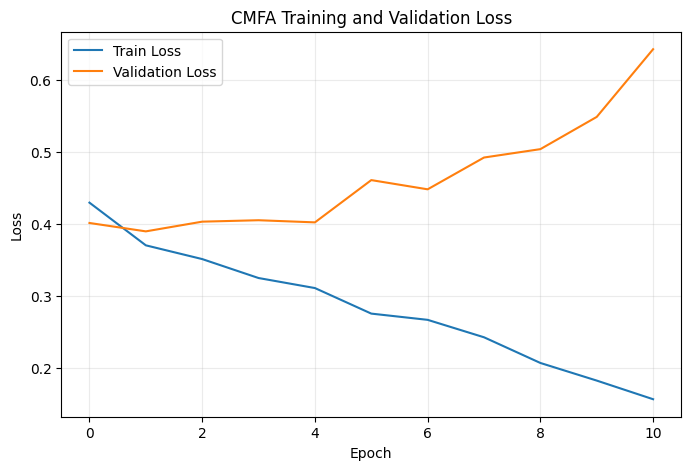

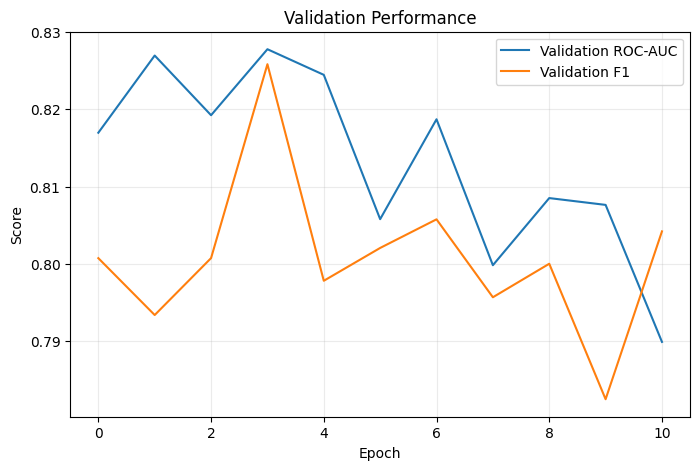

In [16]:
# Cell 11 — Plot training curves
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CMFA Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["val_auc"], label="Validation ROC-AUC")
plt.plot(history["val_f1"], label="Validation F1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Performance")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


=== CMFA TEST METRICS ===
Accuracy                : 0.7667
Precision               : 0.8199
Recall / Sensitivity    : 0.7993
Specificity             : 0.7135
F1 Score                : 0.8094
ROC-AUC                 : 0.8336
PR-AUC                  : 0.8778

Classification report:
                     precision    recall  f1-score   support

No Early Recurrence       0.69      0.71      0.70       171
   Early Recurrence       0.82      0.80      0.81       279

           accuracy                           0.77       450
          macro avg       0.75      0.76      0.75       450
       weighted avg       0.77      0.77      0.77       450



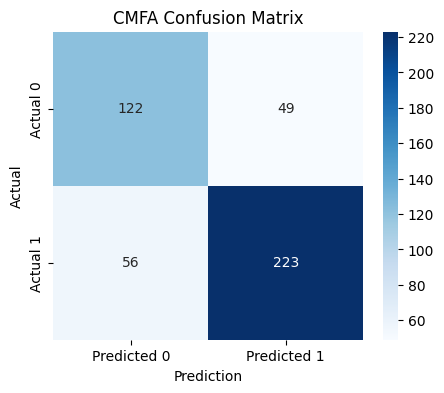

In [17]:
# Cell 12 — Final test evaluation
yt, pt = collect_predictions(model, test_loader)
test_metrics = calculate_metrics(yt, pt, threshold=0.5)

print("=== CMFA TEST METRICS ===")
for name, value in test_metrics.items():
    print(f"{name:24s}: {value:.4f}")

print("\nClassification report:")
print(classification_report(
    yt, (pt >= 0.5).astype(int),
    target_names=["No Early Recurrence", "Early Recurrence"],
    zero_division=0
))

cm = confusion_matrix(yt, (pt >= 0.5).astype(int))
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)
plt.title("CMFA Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.show()


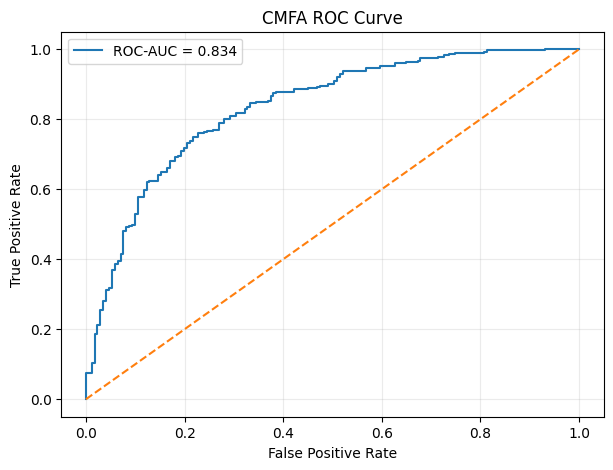

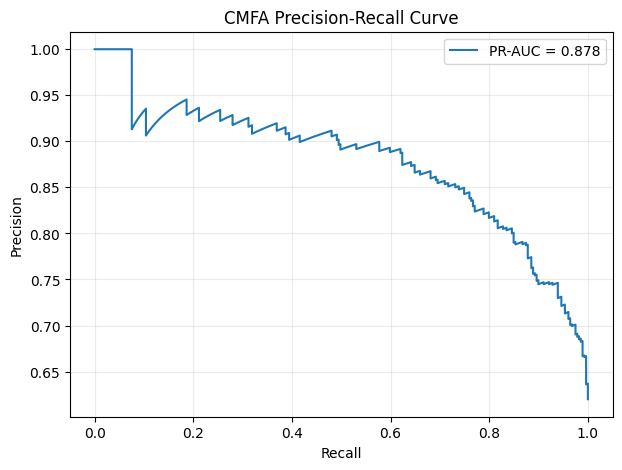

In [18]:
# Cell 13 — ROC and Precision-Recall curves
fpr, tpr, _ = roc_curve(yt, pt)
precision, recall, _ = precision_recall_curve(yt, pt)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {test_metrics['ROC-AUC']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CMFA ROC Curve")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"PR-AUC = {test_metrics['PR-AUC']:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("CMFA Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


Fused representation shape: (8, 128)
Image -> Text attention shape: (8, 4, 4)
Text -> Image attention shape: (8, 4, 4)


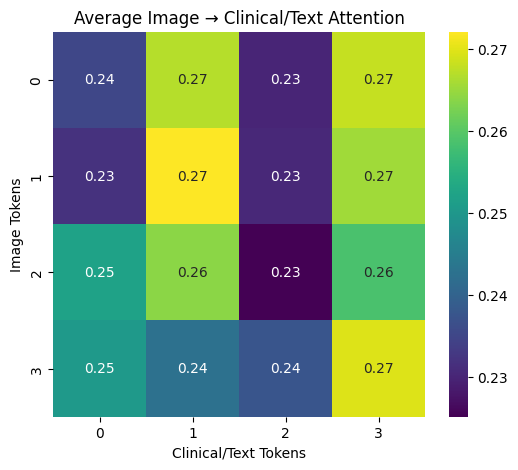

In [19]:
# Cell 14 — Inspect cross-modal attention
# This produces an attention matrix for a few test patients.
# Rows = image tokens, columns = clinical/text tokens.

sample_n = min(8, len(X_img_test))
sample_img = torch.from_numpy(X_img_test[:sample_n]).to(DEVICE)
sample_txt = torch.from_numpy(X_txt_test[:sample_n]).to(DEVICE)

model.eval()
with torch.no_grad():
    logits, fused, attn_i2t, attn_t2i = model(
        sample_img, sample_txt, return_attention=True
    )

print("Fused representation shape:", tuple(fused.shape))
print("Image -> Text attention shape:", tuple(attn_i2t.shape))
print("Text -> Image attention shape:", tuple(attn_t2i.shape))

# Mean attention over sampled patients
mean_i2t = attn_i2t.mean(dim=0).cpu().numpy()

plt.figure(figsize=(6, 5))
sns.heatmap(mean_i2t, annot=True, fmt=".2f", cmap="viridis")
plt.title("Average Image → Clinical/Text Attention")
plt.xlabel("Clinical/Text Tokens")
plt.ylabel("Image Tokens")
plt.show()


In [20]:
# Cell 15 — Create a simple CMFA UI-ready summary
# This gives the frontend/backend useful high-level values.
# The modality weights below are calculated from attention mass, not copied
# from the dataset's downstream attention columns.

with torch.no_grad():
    img_mass = attn_i2t.mean(dim=(1, 2))
    txt_mass = attn_t2i.mean(dim=(1, 2))
    modality_sum = img_mass + txt_mass + 1e-8

    image_weight = (img_mass / modality_sum).cpu().numpy()
    text_weight = (txt_mass / modality_sum).cpu().numpy()

ui_summary = pd.DataFrame({
    "patient_id": test_df["patient_id"].iloc[:sample_n].values,
    "recurrence_probability": torch.sigmoid(logits).squeeze(1).cpu().numpy(),
    "image_attention_weight": image_weight,
    "text_attention_weight": text_weight,
    "fused_feature_dimension": [fused.shape[1]] * sample_n
})

display(ui_summary)


,patient_id,recurrence_probability,image_attention_weight,text_attention_weight,fused_feature_dimension
0,PT2177,0.459585,0.5,0.5,128
1,PT2871,0.779844,0.5,0.5,128
2,PT0659,0.940930,0.5,0.5,128
3,PT0208,0.935294,0.5,0.5,128
4,PT0068,0.903011,0.5,0.5,128
5,PT1997,0.286425,0.5,0.5,128
6,PT2340,0.720832,0.5,0.5,128
7,PT1805,0.758326,0.5,0.5,128


In [21]:
# Cell 16 — Save model and preprocessing artifacts
os.makedirs("artifacts", exist_ok=True)

MODEL_PATH = "artifacts/cmfa_model.pth"
PREPROCESSOR_PATH = "artifacts/cmfa_preprocessors.pkl"
CONFIG_PATH = "artifacts/cmfa_config.json"
METRICS_PATH = "artifacts/cmfa_test_metrics.json"

torch.save(model.state_dict(), MODEL_PATH)

joblib.dump({
    "image_preprocessor": image_preprocessor,
    "text_preprocessor": text_preprocessor,
    "image_features": IMAGE_FEATURES,
    "clinical_text_features": CLINICAL_TEXT_FEATURES,
    "target": TARGET
}, PREPROCESSOR_PATH)

config = {
    "image_input_dim": int(X_img_train.shape[1]),
    "clinical_text_input_dim": int(X_txt_train.shape[1]),
    "d_model": 128,
    "num_heads": 4,
    "num_tokens": 4,
    "dropout": 0.20,
    "threshold": 0.5,
    "seed": SEED
}

with open(CONFIG_PATH, "w") as f:
    json.dump(config, f, indent=2)

with open(METRICS_PATH, "w") as f:
    json.dump({k: float(v) for k, v in test_metrics.items()}, f, indent=2)

print("Saved:")
print(MODEL_PATH)
print(PREPROCESSOR_PATH)
print(CONFIG_PATH)
print(METRICS_PATH)


Saved:
artifacts/cmfa_model.pth
artifacts/cmfa_preprocessors.pkl
artifacts/cmfa_config.json
artifacts/cmfa_test_metrics.json


In [22]:
# Cell 17 — Inference function for backend integration
def predict_patient(image_row: pd.DataFrame, clinical_text_row: pd.DataFrame):
    bundle = joblib.load("artifacts/cmfa_preprocessors.pkl")

    img_x = bundle["image_preprocessor"].transform(
        image_row[bundle["image_features"]]
    ).astype(np.float32)

    txt_x = bundle["text_preprocessor"].transform(
        clinical_text_row[bundle["clinical_text_features"]]
    ).astype(np.float32)

    img_t = torch.from_numpy(img_x).to(DEVICE)
    txt_t = torch.from_numpy(txt_x).to(DEVICE)

    model.eval()
    with torch.no_grad():
        logits, fused, attn_i2t, attn_t2i = model(
            img_t, txt_t, return_attention=True
        )
        probability = torch.sigmoid(logits).item()

    return {
        "recurrence_probability": probability,
        "risk_class": "High Risk" if probability >= 0.5 else "Lower Risk",
        "fused_feature_dimension": int(fused.shape[1]),
        "image_to_text_attention": attn_i2t.cpu().numpy().tolist(),
        "text_to_image_attention": attn_t2i.cpu().numpy().tolist(),
        "fused_feature_vector": fused.cpu().numpy().flatten().tolist()
    }

